# 🧠 Análise Exploratória de Dados

Este notebook realiza uma **análise exploratória detalhada** dos três conjuntos de dados disponíveis (`Data1.csv`, `Data2.csv`, `Data3.csv`).

O objetivo é compreender o comportamento das variáveis de entrada (`PwmD`, `PwmE`) e das variáveis de saída (`Wd`, `We`), identificando padrões, correlações e possíveis problemas como outliers ou desbalanceamento.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.stats import f_oneway

sns.set(style="whitegrid", context="notebook")

PREDICTORS = ["PwmD", "PwmE"]   
TARGET = ["Wd", "We", "X", "Y", "Theta"] 
Datasets = []

for i in range(2):
    Dataset = pd.read_csv(f"../Dados/Data{i + 1}.csv")
    Dataset.index = (np.arange(0, len(Dataset), 1).astype(float) * 0.07).round(5)
    Datasets.append(Dataset)

print(f"Foram carregados {len(Datasets)} datasets.")

Foram carregados 2 datasets.


## 🔍 1. Estrutura dos Dados
Primeiro, verificamos informações gerais sobre o formato de cada dataset, valores ausentes e estatísticas básicas das variáveis.

In [2]:
for i, data in enumerate(Datasets):
    print(f"\n=== Dataset {i+1} ===")
    display(data.info())
    display(data.describe().T)
    print("Valores nulos:")
    print(data.isnull().sum())


=== Dataset 1 ===
<class 'pandas.core.frame.DataFrame'>
Index: 1954 entries, 0.0 to 136.71
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       1954 non-null   float64
 1   Y       1954 non-null   float64
 2   Theta   1954 non-null   float64
 3   Wd      1954 non-null   float64
 4   We      1954 non-null   float64
 5   WdRef   1954 non-null   float64
 6   WeRef   1954 non-null   float64
 7   PwmD    1954 non-null   float64
 8   PwmE    1954 non-null   float64
dtypes: float64(9)
memory usage: 152.7 KB


None

,count,mean,std,min,25%,50%,75%,max
X,1954.0,0.443265,0.317953,0.00,0.1200,0.465,0.71,1.00
Y,1954.0,0.260972,0.318473,-0.30,0.0000,0.230,0.58,0.71
Theta,1954.0,-0.779734,0.927378,-2.85,-1.5900,-0.800,0.00,1.07
Wd,1954.0,-0.220880,2.292340,-3.87,-2.3400,-0.015,1.98,4.68
We,1954.0,-0.198659,2.328374,-4.29,-2.4275,0.000,2.06,4.40
WdRef,1954.0,-0.231392,2.348951,-3.30,-2.2100,-0.970,1.98,3.28
WeRef,1954.0,-0.219606,2.381833,-3.30,-2.2100,-1.000,2.07,3.28
PwmD,1954.0,-16.614985,85.423306,-130.47,-98.5200,-57.450,80.41,115.34
PwmE,1954.0,-9.117103,102.955629,-149.62,-108.0000,-53.550,104.98,160.13


Valores nulos:
X        0
Y        0
Theta    0
Wd       0
We       0
WdRef    0
WeRef    0
PwmD     0
PwmE     0
dtype: int64

=== Dataset 2 ===
<class 'pandas.core.frame.DataFrame'>
Index: 1967 entries, 0.0 to 137.62
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       1967 non-null   float64
 1   Y       1967 non-null   float64
 2   Theta   1967 non-null   float64
 3   Wd      1967 non-null   float64
 4   We      1967 non-null   float64
 5   WdRef   1967 non-null   float64
 6   WeRef   1967 non-null   float64
 7   PwmD    1967 non-null   float64
 8   PwmE    1967 non-null   float64
dtypes: float64(9)
memory usage: 153.7 KB


None

,count,mean,std,min,25%,50%,75%,max
X,1967.0,0.446121,0.313836,0.00,0.130,0.47,0.710,0.99
Y,1967.0,0.253793,0.314253,-0.29,-0.000,0.22,0.570,0.71
Theta,1967.0,-0.786380,0.923914,-2.80,-1.590,-0.79,-0.000,1.16
Wd,1967.0,-0.219919,2.269883,-4.57,-2.340,0.00,2.020,4.66
We,1967.0,-0.199039,2.285561,-4.04,-2.310,0.00,2.120,4.35
WdRef,1967.0,-0.237270,2.301680,-3.30,-2.170,-0.98,2.050,3.28
WeRef,1967.0,-0.217453,2.353615,-3.30,-2.210,-1.01,2.160,3.28
PwmD,1967.0,-17.880452,87.413644,-135.22,-99.325,-66.92,83.800,123.74
PwmE,1967.0,-11.298353,103.549973,-153.15,-109.260,-73.57,106.495,163.80


Valores nulos:
X        0
Y        0
Theta    0
Wd       0
We       0
WdRef    0
WeRef    0
PwmD     0
PwmE     0
dtype: int64


🧩 **Interpretação:**
- A função `info()` revela o número de linhas, tipos de dados e existência de valores nulos.
- O `describe()` mostra estatísticas como média, desvio padrão, mínimo e máximo.
- É importante confirmar que todas as colunas são numéricas e que não há valores ausentes.

## 📊 2. Distribuição das Variáveis
Aqui verificamos a forma das distribuições das variáveis preditoras e alvo. Distribuições simétricas indicam comportamento estável; distribuições assimétricas podem revelar saturação ou zonas mortas no sistema.

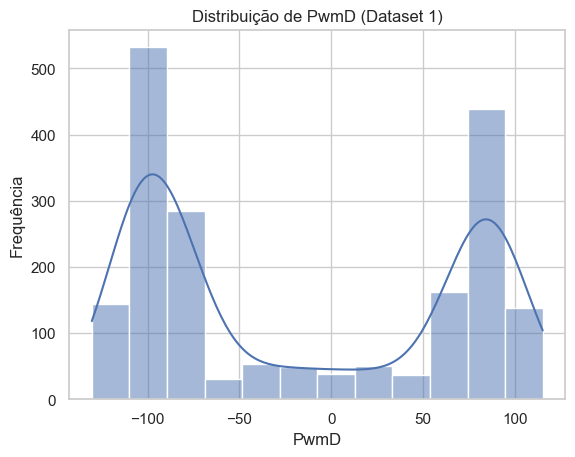

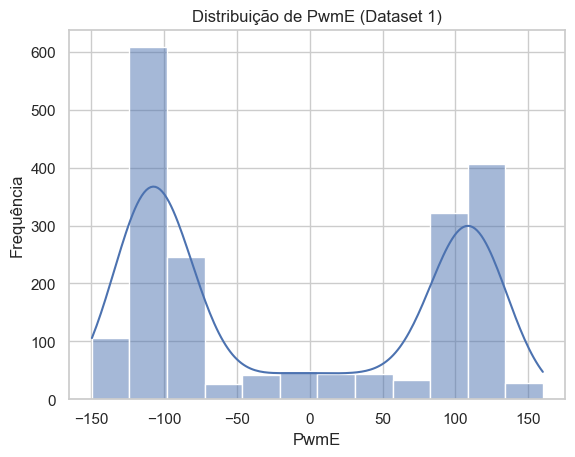

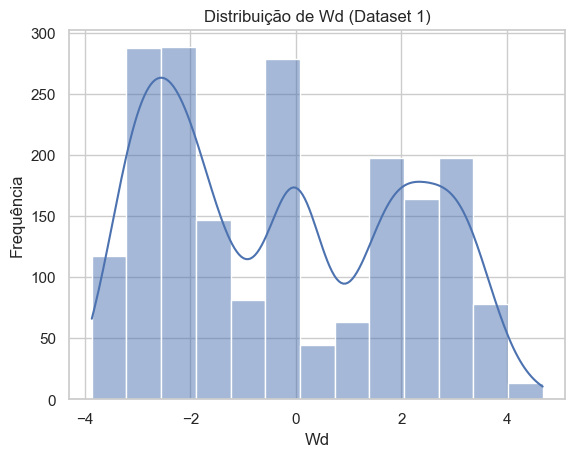

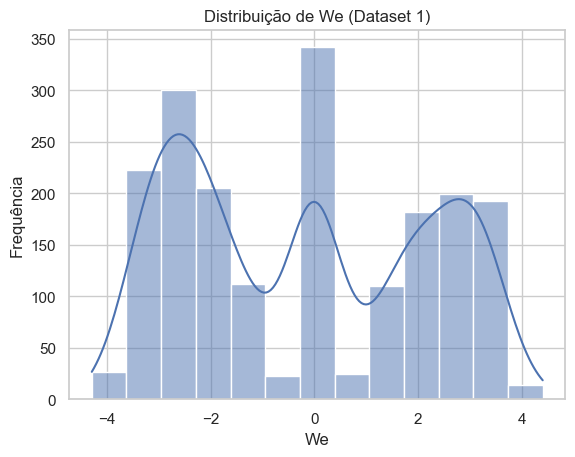

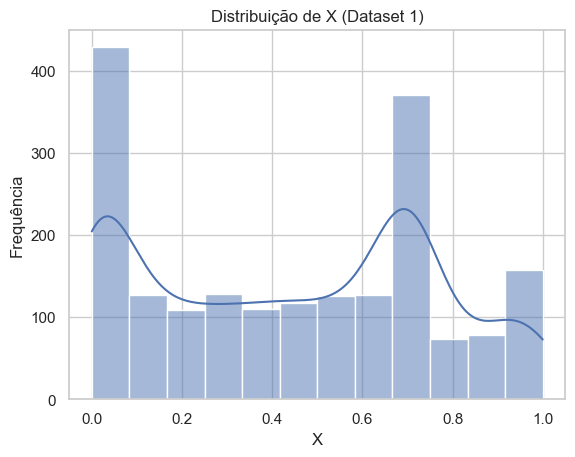

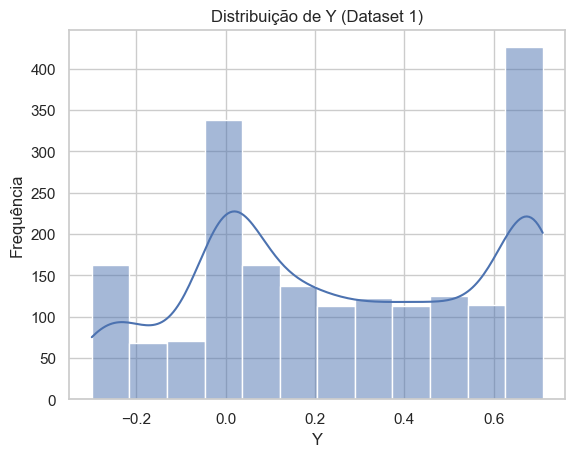

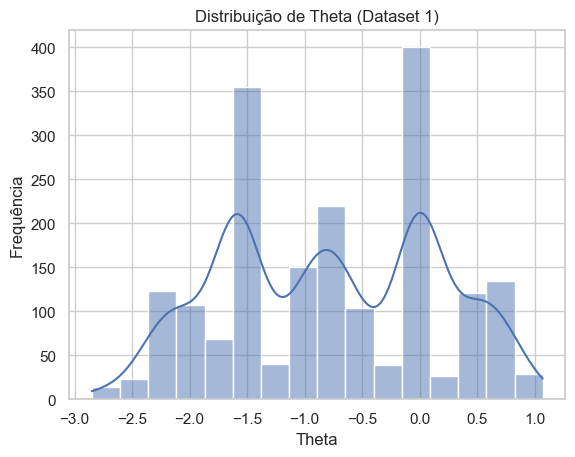

In [3]:
for col in PREDICTORS + TARGET:
    sns.histplot(Datasets[0][col], kde=True)
    plt.title(f"Distribuição de {col} (Dataset 1)")
    plt.xlabel(col)
    plt.ylabel("Frequência")
    plt.show()

📈 **Interpretação:**
- O formato das curvas indica se os dados são normalmente distribuídos ou não.
- Valores muito concentrados em uma faixa indicam possível limitação do sensor ou saturação de controle.
- A presença de várias modas (picos) pode indicar regimes operacionais distintos.

## 🎯 3. Boxplots — Detecção de Outliers
Os boxplots ajudam a visualizar valores fora da faixa esperada (outliers), que podem distorcer médias e correlações.

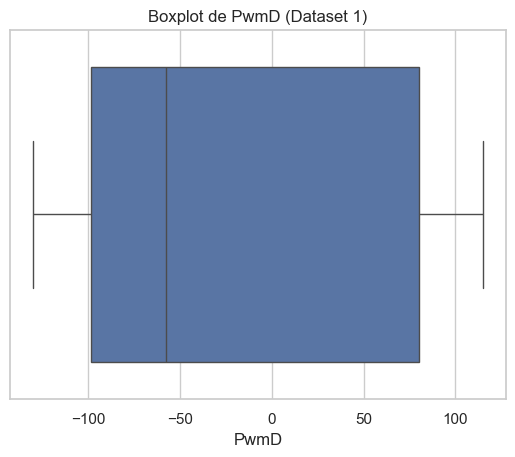

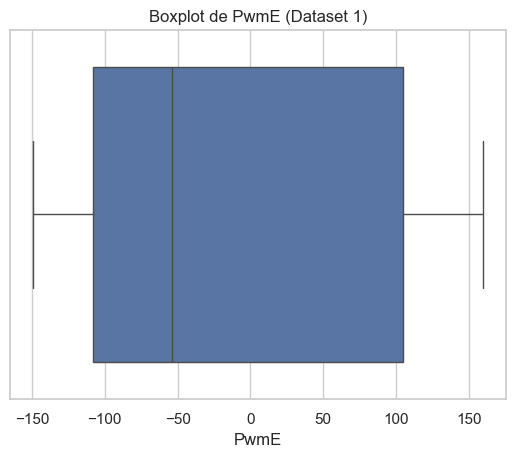

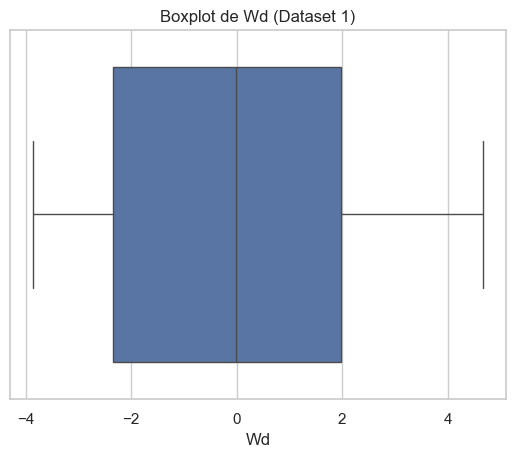

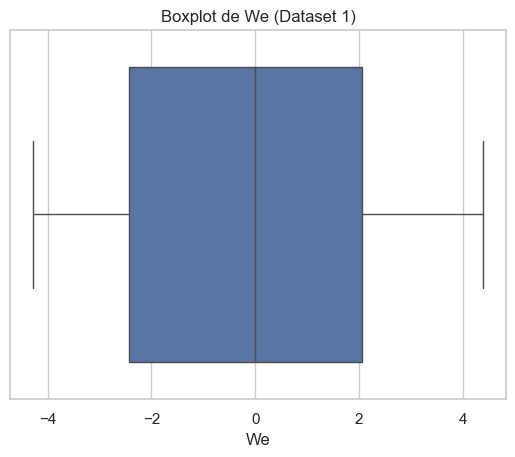

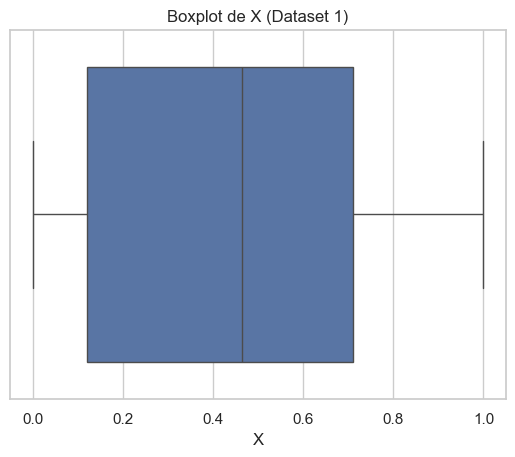

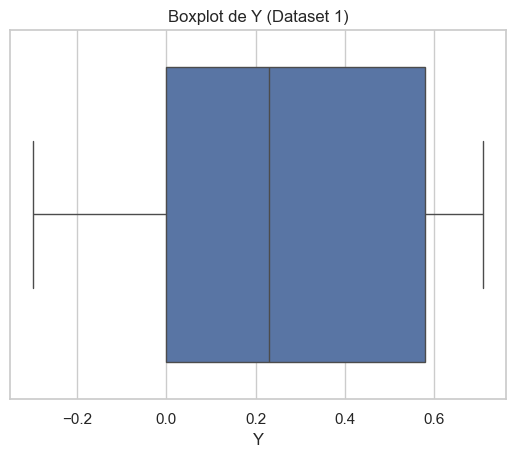

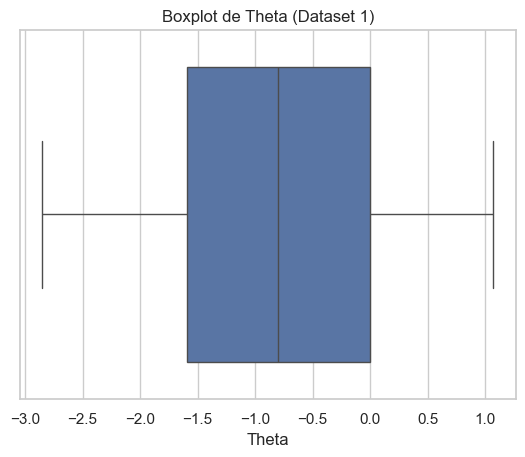

In [4]:
for col in PREDICTORS + TARGET:
    sns.boxplot(x=Datasets[0][col])
    plt.title(f"Boxplot de {col} (Dataset 1)")
    plt.show()

📊 **Interpretação:**
- Pontos fora do intervalo interquartil (caixas) indicam **outliers potenciais**.
- Se forem recorrentes, podem ser dados reais de operação extrema; se raros, podem ser ruído ou erro de medição.

## 🔗 4. Relações entre Variáveis (Pairplot)
O gráfico de dispersão mostra correlações e relações não lineares entre as variáveis de entrada e saída.

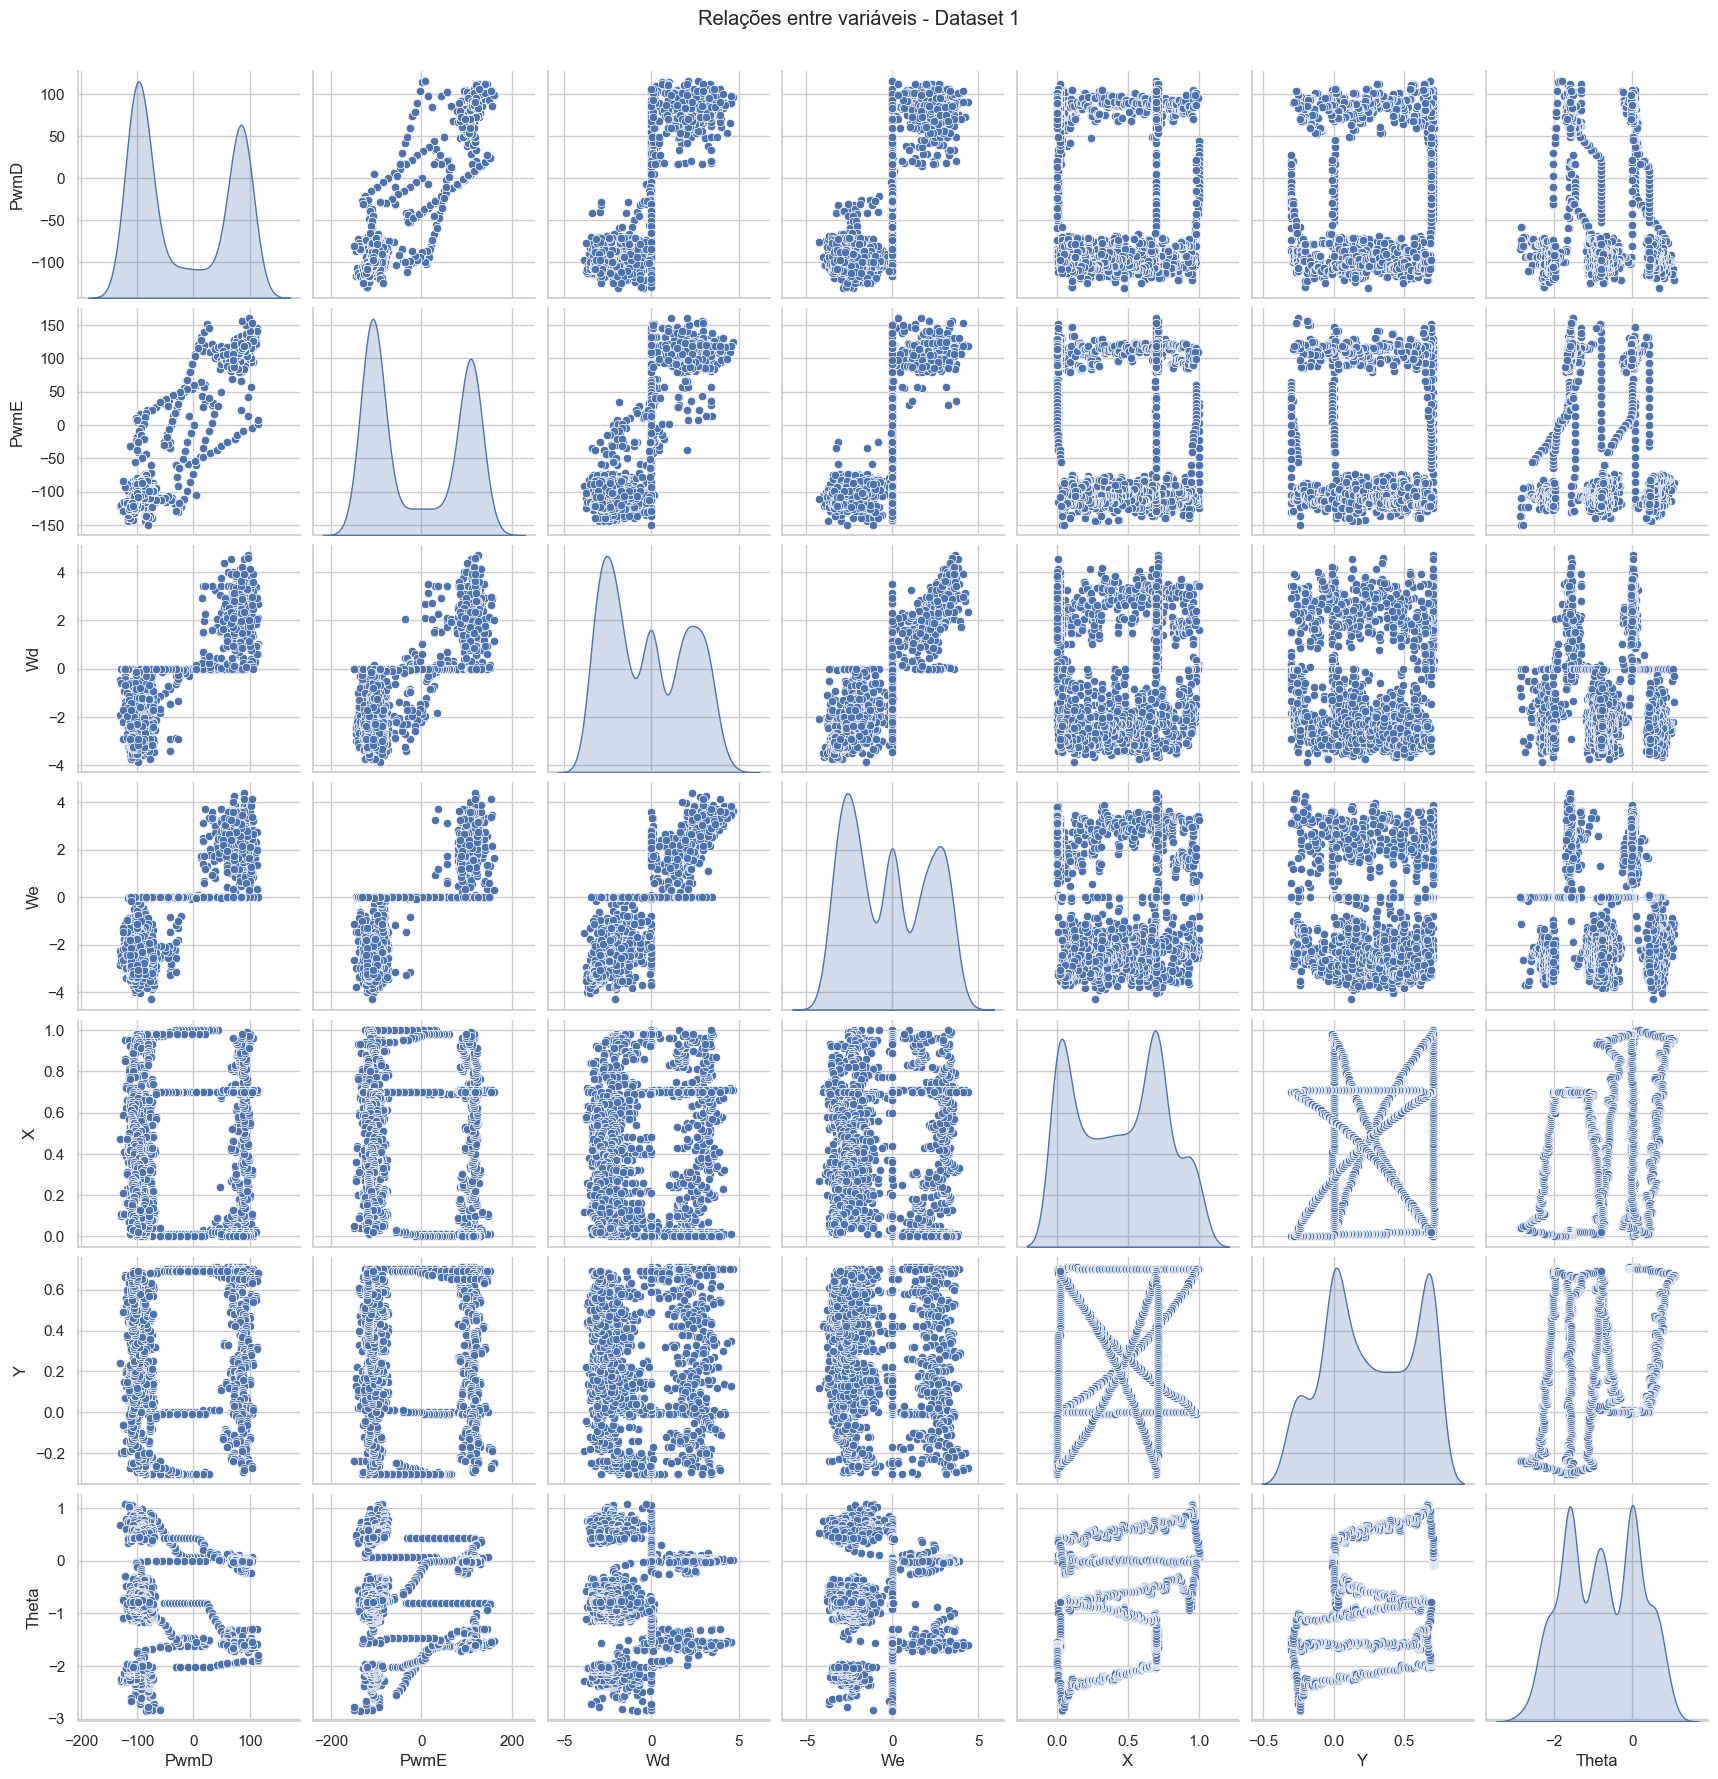

In [5]:
sns.pairplot(Datasets[0][PREDICTORS + TARGET], diag_kind='kde')
plt.suptitle("Relações entre variáveis - Dataset 1", y=1.02)
plt.show()

🧠 **Interpretação:**
- Relações lineares aparecem como nuvens inclinadas.
- Relações não lineares podem ser curvas ou padrões em forma de arco.
- A diagonal mostra a densidade individual de cada variável.

## 🧮 5. Matriz de Correlação
A matriz de correlação ajuda a identificar variáveis fortemente relacionadas entre si.

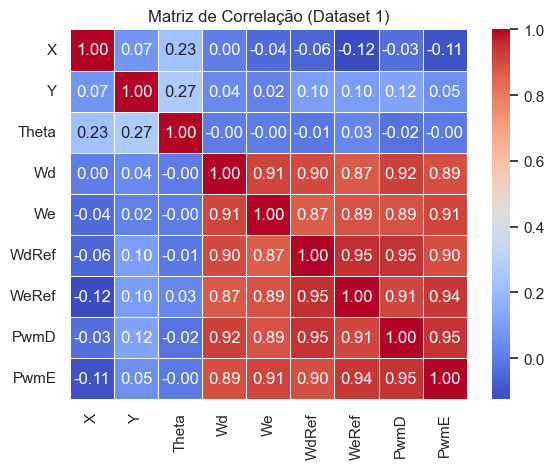

In [6]:
corr = Datasets[0].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title("Matriz de Correlação (Dataset 1)")
plt.show()

📉 **Interpretação:**
- Valores próximos de 1 ou -1 indicam forte correlação.
- Correlações altas entre `PwmD` e `Wd` (ou `PwmE` e `We`) podem indicar uma relação direta de controle.
- Correlações cruzadas (ex.: `PwmD` e `We`) podem revelar acoplamento entre os sistemas.

## ⏱️ 6. Séries Temporais
Visualização das variáveis ao longo do tempo para identificar tendências, oscilações e ruídos.

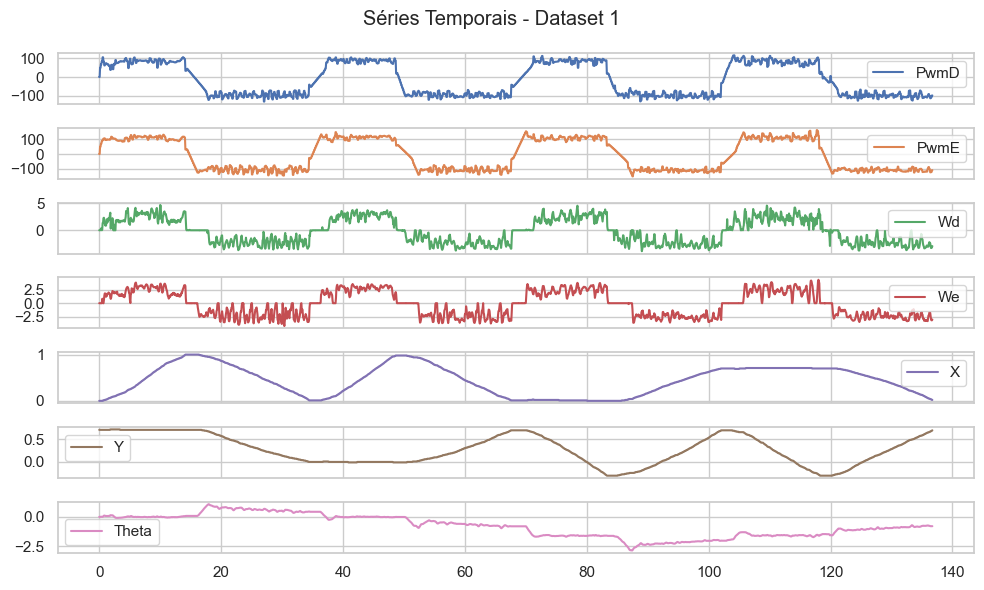

In [7]:
Datasets[0][PREDICTORS + TARGET].plot(subplots=True, figsize=(10,6), title="Séries Temporais - Dataset 1")
plt.tight_layout()
plt.show()

🕒 **Interpretação:**
- Mudanças bruscas indicam transientes.
- Trechos constantes sugerem operação estacionária.
- Padrões periódicos podem indicar um comportamento controlado ou repetitivo.

## ⚙️ 7. Análise de Componentes Principais (PCA)
Usada para identificar redundância entre as variáveis de entrada e avaliar a dimensionalidade dos dados.

Variância explicada: [0.97320157 0.02679843]


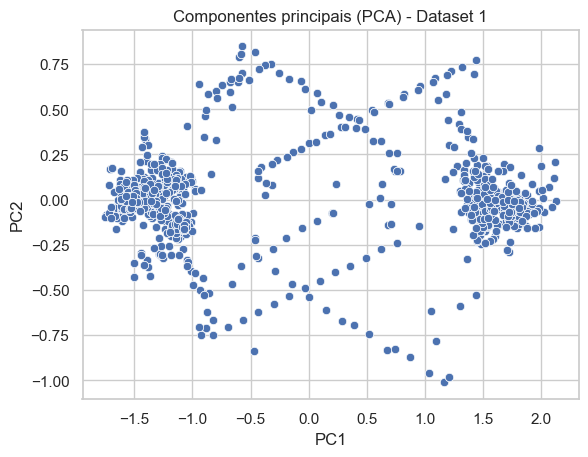

In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(Datasets[0][PREDICTORS])
pca = PCA(n_components=2)
components = pca.fit_transform(X_scaled)
print("Variância explicada:", pca.explained_variance_ratio_)

sns.scatterplot(x=components[:,0], y=components[:,1])
plt.title("Componentes principais (PCA) - Dataset 1")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

📊 **Interpretação:**
- Se uma componente explica grande parte da variância, as variáveis são fortemente correlacionadas.
- Distribuição dispersa indica que ambas as variáveis trazem informação independente.

## 📈 8. Comparação entre Datasets
Verificamos se a média das variáveis alvo muda significativamente entre os três datasets, o que pode indicar mudança de condições experimentais.

ValueError: x and y must have same first dimension, but have shapes (3,) and (2,)

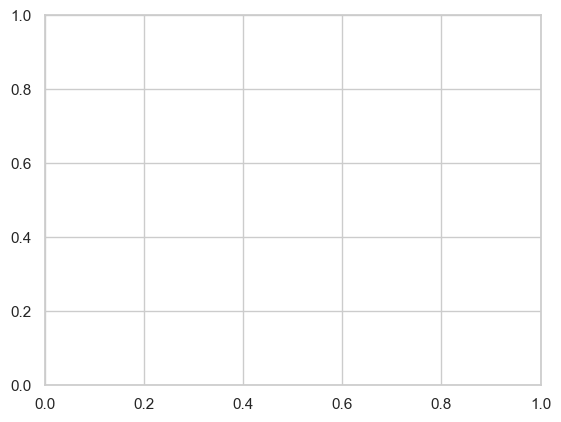

In [9]:
means = [data[TARGET].mean() for data in Datasets]
plt.plot(range(1,4), [m['Wd'] for m in means], 'o-', label='Wd')
plt.plot(range(1,4), [m['We'] for m in means], 'o-', label='We')
plt.legend()
plt.title("Média das variáveis alvo por Dataset")
plt.xlabel("Dataset")
plt.ylabel("Média")
plt.show()

# Teste ANOVA para diferenças significativas
f, p = f_oneway(Datasets[0]['Wd'], Datasets[1]['Wd'], Datasets[2]['Wd'])
print(f"ANOVA para Wd: F={f:.3f}, p={p:.3f}")

📊 **Interpretação:**
- Se as médias diferirem significativamente (p < 0.05), há indícios de mudança no comportamento entre datasets.
- Isso pode indicar variação experimental, ajuste de controle ou condições externas diferentes.

---
## ✅ Conclusão
Esta análise fornece uma visão detalhada sobre o comportamento e qualidade dos dados:
- **Distribuições** ajudam a identificar saturação ou ruído;
- **Boxplots** e **heatmaps** revelam outliers e relações fortes;
- **PCA** mostra redundância nas variáveis;
- **Análises comparativas** indicam estabilidade entre diferentes datasets.

Essas informações são fundamentais antes de qualquer modelagem ou ajuste de sistema.